In [37]:
# import necessary libraries for geospatial analysis
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import plotly.express as px

In [38]:
# import the data from the data file
oak = pd.read_csv('../Group Data/AllOaksinLACounty.csv')
# get a sample of the first five rows of the data file
oak.head(10)

,id,observed_on,latitude,longitude,place_town_name,place_county_name,scientific_name,common_name
0,8010,2010-08-08,34.051315,-118.828232,NaN,Los Angeles,Quercus berberidifolia,California scrub oak
1,16226,2011-04-21,34.099908,-118.723948,NaN,Los Angeles,Quercus lobata,valley oak
2,49531,2012-01-29,34.037792,-118.750244,NaN,Los Angeles,Quercus agrifolia,coast live oak
3,52936,2012-02-21,34.210906,-118.122473,NaN,Los Angeles,Quercus chrysolepis,canyon live oak
4,57187,2012-03-06,34.193470,-118.175340,NaN,Los Angeles,Quercus agrifolia,coast live oak
5,59510,2012-03-22,34.193066,-118.104315,NaN,Los Angeles,Quercus agrifolia,coast live oak
6,91634,2012-06-15,34.060028,-118.932694,NaN,Los Angeles,Quercus agrifolia,coast live oak
7,94373,2012-06-21,34.321234,-118.638375,NaN,Los Angeles,Quercus lobata,valley oak
8,98831,2012-07-04,34.184842,-118.095442,NaN,Los Angeles,Quercus agrifolia,coast live oak
9,103070,2012-07-18,34.188598,-118.177912,NaN,Los Angeles,Quercus agrifolia,coast live oak


In [39]:
# convert clo to a geo data frame
geooak = gpd.GeoDataFrame(oak, 
                       crs='epsg:4326',
                       geometry=gpd.points_from_xy(oak.longitude, oak.latitude))

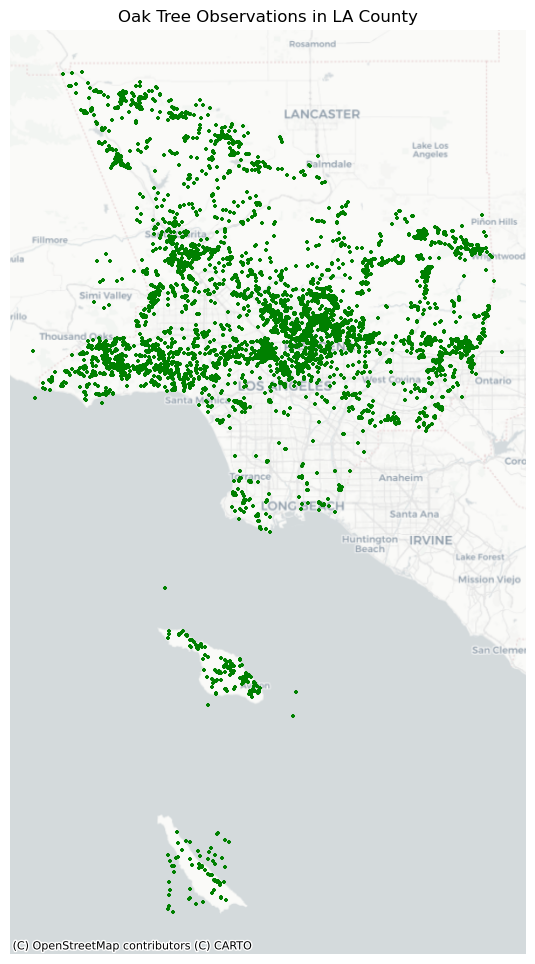

In [40]:
# create a plot with an added basemap to give the plot geographic context
fig, ax = plt.subplots(figsize=(12,12))
geooak.plot(ax=ax, 
        marker='+',
        markersize=10,
        color='green')
ax.axis('off')
ax.set_title('Oak Tree Observations in LA County')
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=4326)

In [41]:
# find the count of all oak species observations in LA County
oak_by_species = oak.value_counts('common_name').reset_index(name='count')
oak_by_species

,common_name,count
0,coast live oak,5807
1,canyon live oak,935
2,valley oak,882
3,California scrub oak,840
4,San Gabriel oak,424
5,Engelmann oak,393
6,Tucker's Oak,239
7,interior live oak,217
8,Ewan's Oak,150
9,California black oak,134


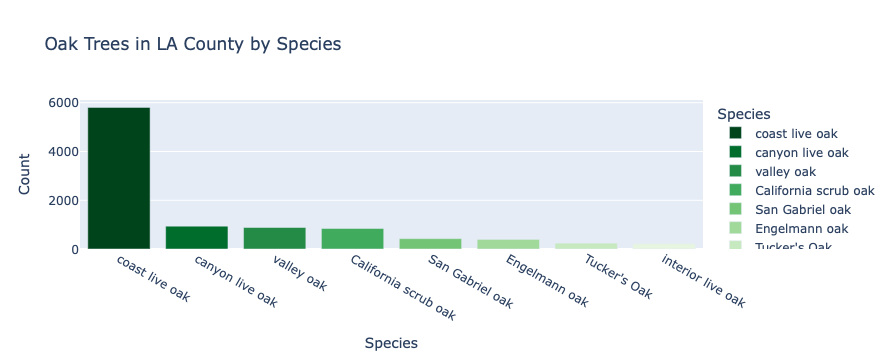

In [42]:
# plot the top 8 observed species
fig = px.bar(oak_by_species.head(8),
       x='common_name',
       y='count',
       title='Oak Trees in LA County by Species',
       color='common_name',
       color_discrete_sequence=px.colors.sequential.Greens_r,
       labels={'common_name': 'Species', 'count': 'Count'})

fig.show()

In [43]:
# import geojson for zip codes
zipcodes = gpd.read_file('../Group Data/LA_County_ZIP_Codes.geojson')

In [44]:
# conduct a spatial join
oak_by_zip = gpd.sjoin(zipcodes, geooak)
oak_by_zip.head(10)

,OBJECTID,ZIPCODE,Shape_Length,Shape_Area,geometry,index_right,id,observed_on,latitude,longitude,place_town_name,place_county_name,scientific_name,common_name
3,4,90004,52471.897635,8.395697e+07,"POLYGON ((-118.2841 34.08349, -118.28438 34.08...",3832,45336986,2020-05-04,34.072811,-118.315812,NaN,Los Angeles,Quercus agrifolia,coast live oak
5,6,90006,37832.454801,5.370366e+07,"POLYGON ((-118.28274 34.03964, -118.28277 34.0...",280,1370257,2015-04-05,34.040585,-118.283162,NaN,Los Angeles,Quercus agrifolia,coast live oak
5,6,90006,37832.454801,5.370366e+07,"POLYGON ((-118.28274 34.03964, -118.28277 34.0...",3151,30893549,2019-08-13,34.051303,-118.285500,NaN,Los Angeles,Quercus lobata,valley oak
6,7,90007,57886.269976,6.859609e+07,"POLYGON ((-118.29297 34.04066, -118.29331 34.0...",7642,172401978,2023-07-11,34.016872,-118.288793,NaN,Los Angeles,Quercus engelmannii,Engelmann oak
6,7,90007,57886.269976,6.859609e+07,"POLYGON ((-118.29297 34.04066, -118.29331 34.0...",167,546837,2014-02-28,34.017257,-118.288591,NaN,Los Angeles,Quercus agrifolia,coast live oak
6,7,90007,57886.269976,6.859609e+07,"POLYGON ((-118.29297 34.04066, -118.29331 34.0...",168,546874,2014-02-28,34.017341,-118.288569,NaN,Los Angeles,Quercus agrifolia,coast live oak
6,7,90007,57886.269976,6.859609e+07,"POLYGON ((-118.29297 34.04066, -118.29331 34.0...",9180,211129809,2024-04-28,34.017468,-118.288385,NaN,Los Angeles,Quercus engelmannii,Engelmann oak
6,7,90007,57886.269976,6.859609e+07,"POLYGON ((-118.29297 34.04066, -118.29331 34.0...",6452,139554812,2022-10-21,34.017481,-118.288384,NaN,Los Angeles,Quercus engelmannii,Engelmann oak
6,7,90007,57886.269976,6.859609e+07,"POLYGON ((-118.29297 34.04066, -118.29331 34.0...",9691,237724501,2024-08-24,34.017502,-118.288892,NaN,Los Angeles,Quercus lobata,valley oak
6,7,90007,57886.269976,6.859609e+07,"POLYGON ((-118.29297 34.04066, -118.29331 34.0...",1878,15916587,2018-08-26,34.017621,-118.288424,NaN,Los Angeles,Quercus engelmannii,Engelmann oak


In [45]:
# count the number of oaks per zip code
oak_counts = oak_by_zip.value_counts('ZIPCODE').reset_index(name='oak_count')
oak_counts

,ZIPCODE,oak_count
0,91001,850
1,91105,826
2,91011,667
3,91107,593
4,91302,528
...,...,...
212,91504,1
213,91722,1
214,91607,1
215,91755,1


In [46]:
# add the count to the zip codes
oak_by_zip = oak_by_zip.merge(oak_counts, how='left',on='ZIPCODE')
oak_by_zip.head(10)

,OBJECTID,ZIPCODE,Shape_Length,Shape_Area,geometry,index_right,id,observed_on,latitude,longitude,place_town_name,place_county_name,scientific_name,common_name,oak_count
0,4,90004,52471.897635,8.395697e+07,"POLYGON ((-118.2841 34.08349, -118.28438 34.08...",3832,45336986,2020-05-04,34.072811,-118.315812,NaN,Los Angeles,Quercus agrifolia,coast live oak,1
1,6,90006,37832.454801,5.370366e+07,"POLYGON ((-118.28274 34.03964, -118.28277 34.0...",280,1370257,2015-04-05,34.040585,-118.283162,NaN,Los Angeles,Quercus agrifolia,coast live oak,2
2,6,90006,37832.454801,5.370366e+07,"POLYGON ((-118.28274 34.03964, -118.28277 34.0...",3151,30893549,2019-08-13,34.051303,-118.285500,NaN,Los Angeles,Quercus lobata,valley oak,2
3,7,90007,57886.269976,6.859609e+07,"POLYGON ((-118.29297 34.04066, -118.29331 34.0...",7642,172401978,2023-07-11,34.016872,-118.288793,NaN,Los Angeles,Quercus engelmannii,Engelmann oak,12
4,7,90007,57886.269976,6.859609e+07,"POLYGON ((-118.29297 34.04066, -118.29331 34.0...",167,546837,2014-02-28,34.017257,-118.288591,NaN,Los Angeles,Quercus agrifolia,coast live oak,12
5,7,90007,57886.269976,6.859609e+07,"POLYGON ((-118.29297 34.04066, -118.29331 34.0...",168,546874,2014-02-28,34.017341,-118.288569,NaN,Los Angeles,Quercus agrifolia,coast live oak,12
6,7,90007,57886.269976,6.859609e+07,"POLYGON ((-118.29297 34.04066, -118.29331 34.0...",9180,211129809,2024-04-28,34.017468,-118.288385,NaN,Los Angeles,Quercus engelmannii,Engelmann oak,12
7,7,90007,57886.269976,6.859609e+07,"POLYGON ((-118.29297 34.04066, -118.29331 34.0...",6452,139554812,2022-10-21,34.017481,-118.288384,NaN,Los Angeles,Quercus engelmannii,Engelmann oak,12
8,7,90007,57886.269976,6.859609e+07,"POLYGON ((-118.29297 34.04066, -118.29331 34.0...",9691,237724501,2024-08-24,34.017502,-118.288892,NaN,Los Angeles,Quercus lobata,valley oak,12
9,7,90007,57886.269976,6.859609e+07,"POLYGON ((-118.29297 34.04066, -118.29331 34.0...",1878,15916587,2018-08-26,34.017621,-118.288424,NaN,Los Angeles,Quercus engelmannii,Engelmann oak,12


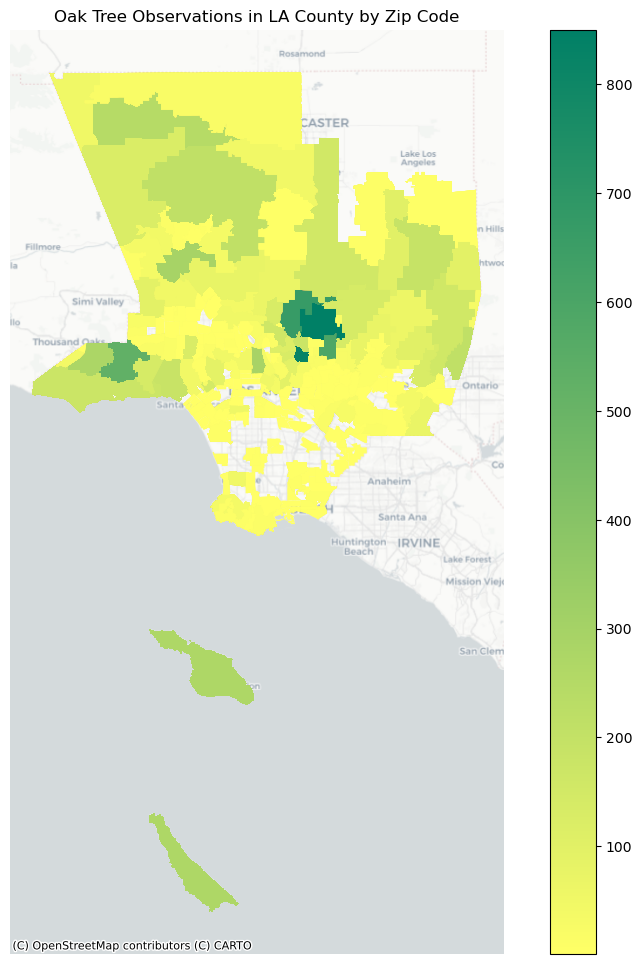

In [47]:
# choropleth map of oaks by zipcode
fig,ax = plt.subplots(figsize=(12,12))

oak_by_zip.plot(ax=ax,column='oak_count',legend=True,cmap='summer_r')
ax.axis('off')
ax.set_title('Oak Tree Observations in LA County by Zip Code')
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=4326)
plt.savefig('Completed Maps/oaksbyzip.jpg')

In [48]:
# consolidate oak species into categories
geooak['common_name'] = geooak['common_name'].astype(str)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Coast Live Oak' if 'Coast Live × Interior Live Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Coast Live Oak' if 'coast live oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Canyon Live Oak' if 'canyon live oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Valley Oak' if 'valley oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'California Scrub Oak' if 'California scrub oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'San Gabriel Oak' if 'San Gabriel oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Engelmann Oak' if 'Engelmann oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Interior Live Oak' if 'interior live oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'California black oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'Bush Interior Live Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'Southern Coast Live Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'southern live oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'California Live Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Interior Live Oak' if 'Interior live oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Valley Oak' if 'Scrub × Valley Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'island scrub oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'island oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if "Nuttall's scrub oak" in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'nan' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'Holm oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'leather oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'blue oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'Shin Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'oaks' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'MacDonald Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'Alvord Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if "Howell's Oak" in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'Jolon Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'Oracle Oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'high-latitude oaks' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if "Muller's oak" in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'Oregon oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if "Palmer's oak" in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if "Torrey's Hybrid Oak" in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'pin oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'northern red oak' in x else x)
geooak['common_name'] = geooak['common_name'].apply(lambda x: 'Oak (Other)' if 'huckleberry oak' in x else x)

# display a list of all variables to test for efficacy
geooak['common_name'].value_counts()

common_name
Coast Live Oak          5814
Oak (Other)              965
Canyon Live Oak          935
Valley Oak               907
California Scrub Oak     840
San Gabriel Oak          424
Engelmann Oak            393
Tucker's Oak             239
Interior Live Oak        218
Ewan's Oak               150
Name: count, dtype: int64

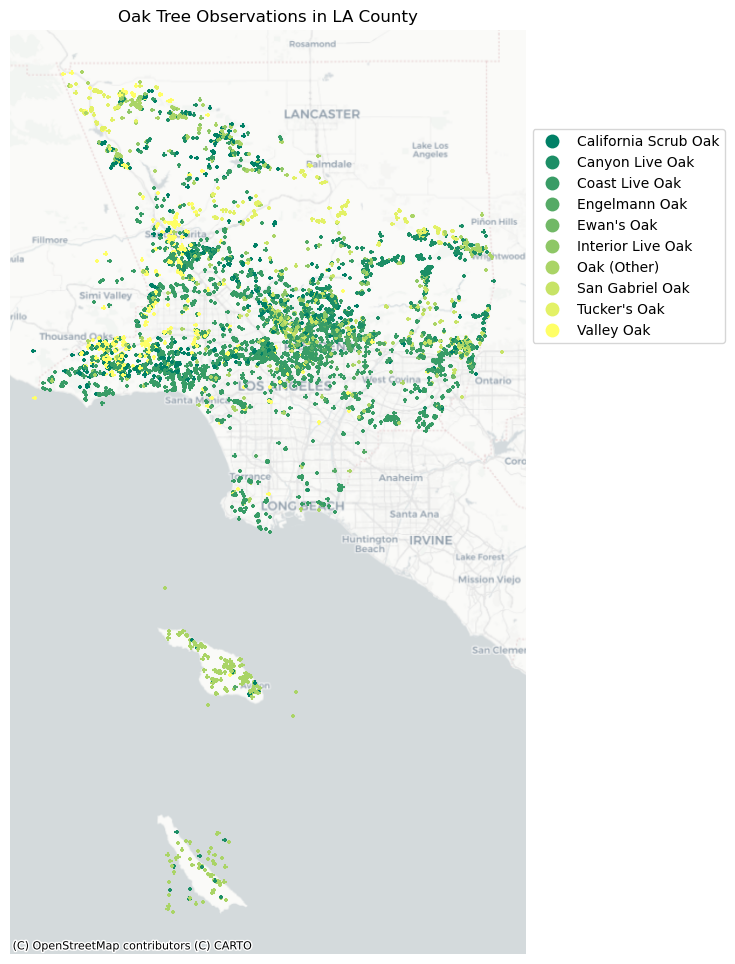

In [49]:
fig, ax = plt.subplots(figsize=(12,12))
geooak.plot(ax=ax, 
        marker='+',
        markersize=10,
        column='common_name',
        cmap='summer',
        legend = True,     
        legend_kwds={'loc':'upper left','bbox_to_anchor':(1,.9)})
ax.axis('off')
ax.set_title('Oak Tree Observations in LA County')
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=4326)
plt.savefig('Completed Maps/oaktrees.jpg')

In [50]:
# import census tracts
census = gpd.read_file('../Group Data/tigerLine-tracts-2022.zip')
census = census.to_crs(crs='EPSG:4326')

In [51]:
# conduct a spatial join
oak_by_tract = gpd.sjoin(census, geooak)
oak_by_tract.head(10)

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,...,geometry,index_right,id,observed_on,latitude,longitude,place_town_name,place_county_name,scientific_name,common_name
0,06,037,137504,06037137504,1375.04,Census Tract 1375.04,G5020,S,3837562,0,...,"POLYGON ((-118.58119 34.14318, -118.581 34.143...",9387,220570286,2024-06-04,34.133678,-118.569345,NaN,Los Angeles,Quercus agrifolia,Coast Live Oak
0,06,037,137504,06037137504,1375.04,Census Tract 1375.04,G5020,S,3837562,0,...,"POLYGON ((-118.58119 34.14318, -118.581 34.143...",4215,66208248,2020-12-06,34.145303,-118.576203,NaN,Los Angeles,Quercus agrifolia,Coast Live Oak
0,06,037,137504,06037137504,1375.04,Census Tract 1375.04,G5020,S,3837562,0,...,"POLYGON ((-118.58119 34.14318, -118.581 34.143...",4024,59741379,2020-09-10,34.146073,-118.567611,NaN,Los Angeles,Quercus agrifolia,Coast Live Oak
0,06,037,137504,06037137504,1375.04,Census Tract 1375.04,G5020,S,3837562,0,...,"POLYGON ((-118.58119 34.14318, -118.581 34.143...",9229,212765740,2024-04-27,34.154035,-118.566391,NaN,Los Angeles,Quercus agrifolia,Coast Live Oak
0,06,037,137504,06037137504,1375.04,Census Tract 1375.04,G5020,S,3837562,0,...,"POLYGON ((-118.58119 34.14318, -118.581 34.143...",7134,152569569,2023-03-27,34.154167,-118.566521,NaN,Los Angeles,Quercus berberidifolia,California Scrub Oak
0,06,037,137504,06037137504,1375.04,Census Tract 1375.04,G5020,S,3837562,0,...,"POLYGON ((-118.58119 34.14318, -118.581 34.143...",6771,145160418,2022-12-26,34.154312,-118.566241,NaN,Los Angeles,Quercus berberidifolia,California Scrub Oak
0,06,037,137504,06037137504,1375.04,Census Tract 1375.04,G5020,S,3837562,0,...,"POLYGON ((-118.58119 34.14318, -118.581 34.143...",1518,10502802,2018-03-29,34.154361,-118.566341,NaN,Los Angeles,Quercus berberidifolia,California Scrub Oak
0,06,037,137504,06037137504,1375.04,Census Tract 1375.04,G5020,S,3837562,0,...,"POLYGON ((-118.58119 34.14318, -118.581 34.143...",4252,67322999,2020-12-29,34.155428,-118.565996,NaN,Los Angeles,Quercus agrifolia,Coast Live Oak
1,06,037,138000,06037138000,1380,Census Tract 1380,G5020,S,4472196,0,...,"POLYGON ((-118.60573 34.14585, -118.60561 34.1...",2067,16861506,2018-09-23,34.155806,-118.585861,NaN,Los Angeles,Quercus agrifolia,Coast Live Oak
1,06,037,138000,06037138000,1380,Census Tract 1380,G5020,S,4472196,0,...,"POLYGON ((-118.60573 34.14585, -118.60561 34.1...",8855,201828244,2023-09-10,34.156369,-118.585953,NaN,Los Angeles,Quercus lobata,Valley Oak


In [52]:
# count the number of oaks per tract
oak_counts1 = oak_by_tract.value_counts('GEOID').reset_index(name='oak_count')
oak_counts1

,GEOID,oak_count
0,06037930400,1554
1,06037460001,484
2,06037460101,388
3,06037800335,376
4,06037460401,343
...,...,...
584,06037920340,1
585,06037980012,1
586,06037980016,1
587,06037102103,1


In [53]:
# add the count to the tracts
oak_by_tract = oak_by_tract.merge(oak_counts1, how='left',on='GEOID')
oak_by_tract.head(10)

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,...,index_right,id,observed_on,latitude,longitude,place_town_name,place_county_name,scientific_name,common_name,oak_count
0,06,037,137504,06037137504,1375.04,Census Tract 1375.04,G5020,S,3837562,0,...,9387,220570286,2024-06-04,34.133678,-118.569345,NaN,Los Angeles,Quercus agrifolia,Coast Live Oak,8
1,06,037,137504,06037137504,1375.04,Census Tract 1375.04,G5020,S,3837562,0,...,4215,66208248,2020-12-06,34.145303,-118.576203,NaN,Los Angeles,Quercus agrifolia,Coast Live Oak,8
2,06,037,137504,06037137504,1375.04,Census Tract 1375.04,G5020,S,3837562,0,...,4024,59741379,2020-09-10,34.146073,-118.567611,NaN,Los Angeles,Quercus agrifolia,Coast Live Oak,8
3,06,037,137504,06037137504,1375.04,Census Tract 1375.04,G5020,S,3837562,0,...,9229,212765740,2024-04-27,34.154035,-118.566391,NaN,Los Angeles,Quercus agrifolia,Coast Live Oak,8
4,06,037,137504,06037137504,1375.04,Census Tract 1375.04,G5020,S,3837562,0,...,7134,152569569,2023-03-27,34.154167,-118.566521,NaN,Los Angeles,Quercus berberidifolia,California Scrub Oak,8
5,06,037,137504,06037137504,1375.04,Census Tract 1375.04,G5020,S,3837562,0,...,6771,145160418,2022-12-26,34.154312,-118.566241,NaN,Los Angeles,Quercus berberidifolia,California Scrub Oak,8
6,06,037,137504,06037137504,1375.04,Census Tract 1375.04,G5020,S,3837562,0,...,1518,10502802,2018-03-29,34.154361,-118.566341,NaN,Los Angeles,Quercus berberidifolia,California Scrub Oak,8
7,06,037,137504,06037137504,1375.04,Census Tract 1375.04,G5020,S,3837562,0,...,4252,67322999,2020-12-29,34.155428,-118.565996,NaN,Los Angeles,Quercus agrifolia,Coast Live Oak,8
8,06,037,138000,06037138000,1380,Census Tract 1380,G5020,S,4472196,0,...,2067,16861506,2018-09-23,34.155806,-118.585861,NaN,Los Angeles,Quercus agrifolia,Coast Live Oak,2
9,06,037,138000,06037138000,1380,Census Tract 1380,G5020,S,4472196,0,...,8855,201828244,2023-09-10,34.156369,-118.585953,NaN,Los Angeles,Quercus lobata,Valley Oak,2


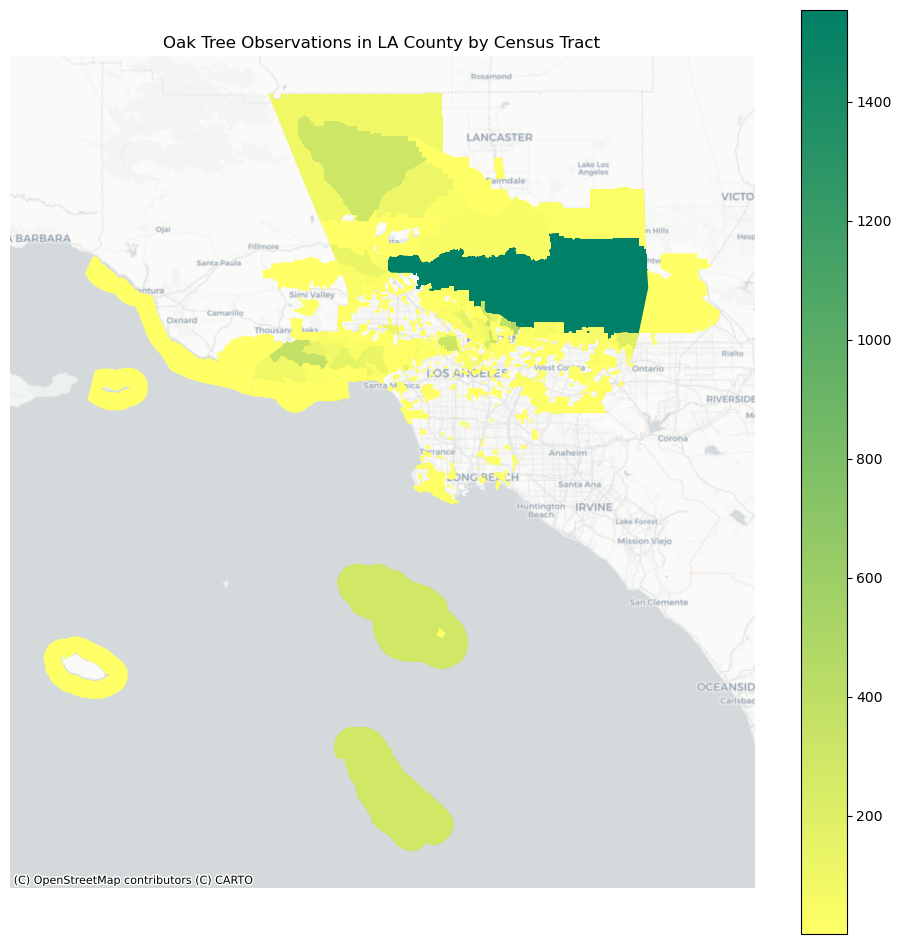

In [54]:
# choropleth map of oaks by tracts
fig,ax = plt.subplots(figsize=(12,12))

oak_by_tract.plot(ax=ax,column='oak_count',legend=True,cmap='summer_r')
ax.axis('off')
ax.set_title('Oak Tree Observations in LA County by Census Tract')
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=4326)
plt.savefig('Completed Maps/oaksbytract.jpg')

In [55]:
# standardize the naming conventions of the variables seen in the observed species chart
oak_by_species['common_name'] = oak_by_species['common_name'].apply(lambda x: 'Coast Live Oak' if 'Coast Live × Interior Live Oak' in x else x)
oak_by_species['common_name'] = oak_by_species['common_name'].apply(lambda x: 'Coast Live Oak' if 'coast live oak' in x else x)
oak_by_species['common_name'] = oak_by_species['common_name'].apply(lambda x: 'Canyon Live Oak' if 'canyon live oak' in x else x)
oak_by_species['common_name'] = oak_by_species['common_name'].apply(lambda x: 'Valley Oak' if 'valley oak' in x else x)
oak_by_species['common_name'] = oak_by_species['common_name'].apply(lambda x: 'California Scrub Oak' if 'California scrub oak' in x else x)
oak_by_species['common_name'] = oak_by_species['common_name'].apply(lambda x: 'San Gabriel Oak' if 'San Gabriel oak' in x else x)
oak_by_species['common_name'] = oak_by_species['common_name'].apply(lambda x: 'Engelmann Oak' if 'Engelmann oak' in x else x)
oak_by_species['common_name'] = oak_by_species['common_name'].apply(lambda x: 'Interior Live Oak' if 'interior live oak' in x else x)
# plot the top 8 observed species
fig = px.bar(oak_by_species.head(8),
       x='common_name',
       y='count',
       title='Oak Trees in LA County by Species',
       color='common_name',
       color_discrete_sequence=px.colors.sequential.Greens_r,
       labels={'common_name': 'Species', 'count': 'Count'})

fig.show()

In [56]:
# load census data file for LA County
dem = pd.read_csv('../Group Data/RacialDemographics.csv')
# ensure that the FIPS column is read as a string
dem = pd.read_csv(
    '../Group Data/RacialDemographics.csv',
    dtype=
    {
        'FIPS':str
    }
)

In [57]:
# select columns that have demographic information that will be useful for our analysis
columns_to_keep = ['FIPS',
                   'DP05_0068E',
                   'DP05_0069E',
                   'DP05_0070E',
                   'DP05_0071E',
                   'DP05_0072E',
                   'DP05_0073E',
                   'DP05_0076E',
                   'DP05_0082PE',
                   'Percent Nonwhite']
# create a new dem variable that contains just the aforementioned columns
dem2 = dem[columns_to_keep]

In [58]:
# rename selected columns stored under dem2
dem2.columns = ['GEOID',
'Total Population',
'Total White Population',
'Total Black Population',
'Total Indigenous Population',
'Total Asian Population',
'Total Pacific Islander Population',
'Total Latino Population (Any Race)',
'Percent White',
'Percent Nonwhite']
# create a sample of the data to ensure columns were correctly renamed
dem2.sample(8)

,GEOID,Total Population,Total White Population,Total Black Population,Total Indigenous Population,Total Asian Population,Total Pacific Islander Population,Total Latino Population (Any Race),Percent White,Percent Nonwhite
2238,06037700102,4505,3582,569,106,290,0,594,66.5,33.5
2396,06037910814,3108,2597,11,127,220,39,896,62.2,37.8
992,06037271500,2928,2237,286,44,510,66,369,62.1,37.9
1206,06037401706,4533,2282,298,110,742,25,2270,26.3,73.7
2184,06037650004,4386,1484,493,59,1966,0,1413,13.8,86.2
1453,06037460001,1853,1412,26,5,385,0,150,69.5,30.5
594,06037207303,2359,1163,597,85,593,47,476,36.0,64.0
2335,06037901007,2104,1682,336,34,113,7,635,48.0,52.0


In [59]:
# setting up data file to only ouptut the necessary columns
census1 = census[['GEOID','geometry']]

In [60]:
census1['GEOID'] = census1['GEOID'].astype('str')
# join together two data sets
tract_dem=census1.merge(dem2,on="GEOID")
# display the first five values to ensure efficacy
tract_dem.head()

/opt/conda/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,GEOID,geometry,Total Population,Total White Population,Total Black Population,Total Indigenous Population,Total Asian Population,Total Pacific Islander Population,Total Latino Population (Any Race),Percent White,Percent Nonwhite
0,06037137504,"POLYGON ((-118.58119 34.14318, -118.581 34.143...",1889,1562,211,17,307,50,306,62.4,37.6
1,06037138000,"POLYGON ((-118.60573 34.14585, -118.60561 34.1...",4777,4441,268,22,284,35,315,80.2,19.8
2,06037139200,"POLYGON ((-118.53083 34.18024, -118.52952 34.1...",5758,4773,328,190,421,0,874,70.3,29.7
3,06037143200,"POLYGON ((-118.37899 34.15409, -118.37888 34.1...",4215,3003,410,41,597,0,1239,50.2,49.8
4,06037201301,"POLYGON ((-118.19304 34.0859, -118.19294 34.08...",3403,1520,234,93,692,0,2047,12.4,87.6


AttributeError: PositGron

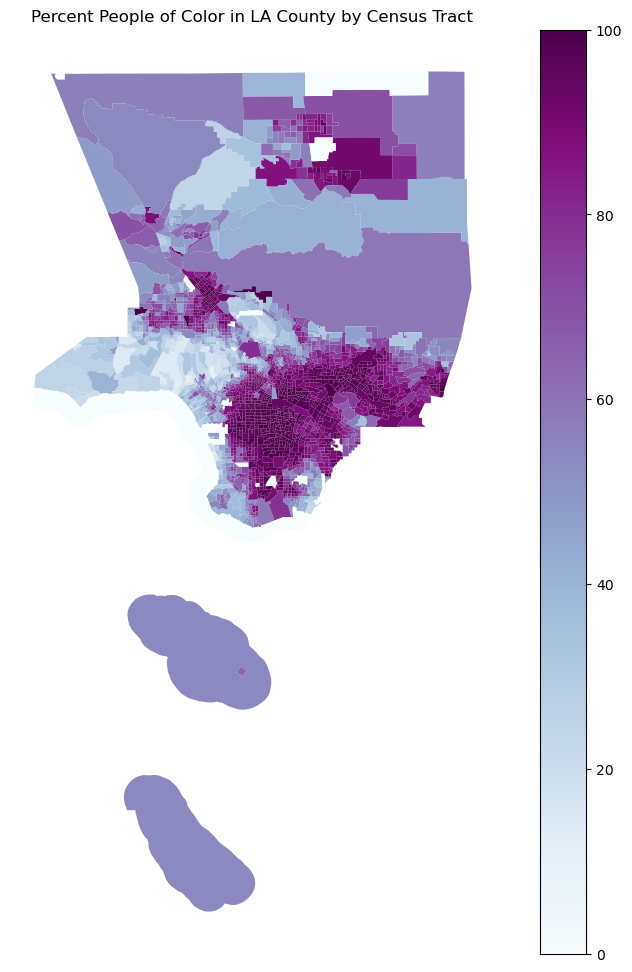

In [61]:
# ouput a map of Los Angeles County showing census tracts by percentage of people of color
fig,ax = plt.subplots(figsize=(12,12))

tract_dem.plot(ax=ax,column='Percent Nonwhite',legend=True,cmap='BuPu')
ax.axis('off')
ax.set_title('Percent People of Color in LA County by Census Tract')
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositGron, crs=4326)
plt.savefig('Completed Maps/pocbytract.jpg')

In [62]:
# merge oak data with demographic data
oak_dem=tract_dem.merge(oak_by_tract,on="GEOID")
oak_dem.head(5)

,GEOID,geometry_x,Total Population,Total White Population,Total Black Population,Total Indigenous Population,Total Asian Population,Total Pacific Islander Population,Total Latino Population (Any Race),Percent White,...,index_right,id,observed_on,latitude,longitude,place_town_name,place_county_name,scientific_name,common_name,oak_count
0,06037137504,"POLYGON ((-118.58119 34.14318, -118.581 34.143...",1889,1562,211,17,307,50,306,62.4,...,9387,220570286,2024-06-04,34.133678,-118.569345,NaN,Los Angeles,Quercus agrifolia,Coast Live Oak,8
1,06037137504,"POLYGON ((-118.58119 34.14318, -118.581 34.143...",1889,1562,211,17,307,50,306,62.4,...,4215,66208248,2020-12-06,34.145303,-118.576203,NaN,Los Angeles,Quercus agrifolia,Coast Live Oak,8
2,06037137504,"POLYGON ((-118.58119 34.14318, -118.581 34.143...",1889,1562,211,17,307,50,306,62.4,...,4024,59741379,2020-09-10,34.146073,-118.567611,NaN,Los Angeles,Quercus agrifolia,Coast Live Oak,8
3,06037137504,"POLYGON ((-118.58119 34.14318, -118.581 34.143...",1889,1562,211,17,307,50,306,62.4,...,9229,212765740,2024-04-27,34.154035,-118.566391,NaN,Los Angeles,Quercus agrifolia,Coast Live Oak,8
4,06037137504,"POLYGON ((-118.58119 34.14318, -118.581 34.143...",1889,1562,211,17,307,50,306,62.4,...,7134,152569569,2023-03-27,34.154167,-118.566521,NaN,Los Angeles,Quercus berberidifolia,California Scrub Oak,8


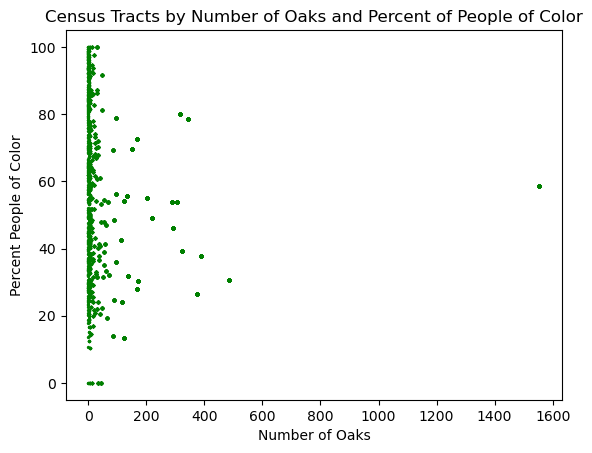

In [63]:
# create a scatter plot with "Number of Oaks" column on the x axis and "Percent Nonwhite" on the y axis
oak_dem.plot.scatter(x='oak_count',
                     y='Percent Nonwhite',
                     title='Census Tracts by Number of Oaks and Percent of People of Color',
                     color='Green',
                     xlabel='Number of Oaks',
                     ylabel='Percent People of Color',
                     s=2)
plt.savefig('Completed Maps/oakbypoc.jpg')

In [64]:
oak_grouped = oak_dem.value_counts(['Percent Nonwhite','common_name','GEOID']).reset_index(name='count')
oak_grouped

,Percent Nonwhite,common_name,GEOID,count
0,58.7,Canyon Live Oak,06037930400,624
1,30.5,Coast Live Oak,06037460001,392
2,58.7,Coast Live Oak,06037930400,349
3,46.2,Coast Live Oak,06037461700,283
4,78.4,Coast Live Oak,06037460401,273
...,...,...,...,...
1094,98.2,Coast Live Oak,06037402501,1
1095,98.1,Coast Live Oak,06037432901,1
1096,98.0,Coast Live Oak,06037432602,1
1097,97.9,Coast Live Oak,06037199900,1


In [65]:
oak_filtered = oak_grouped.dropna(subset=['count'])

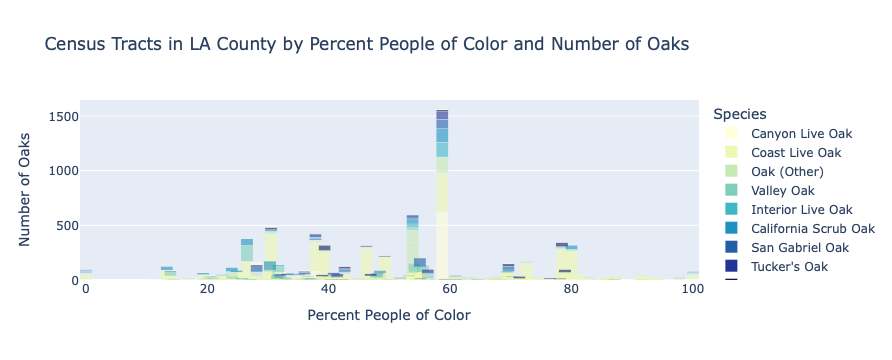

In [66]:
fig = px.bar(oak_filtered,
       x='Percent Nonwhite',
       y='count',
       color='common_name',
       color_discrete_sequence=px.colors.sequential.YlGnBu,
       labels={'Percent Nonwhite': 'Percent People of Color', 'count': 'Number of Oaks','common_name': 'Species'},
       title='Census Tracts in LA County by Percent People of Color and Number of Oaks'
)
fig.update_traces(marker_line_width=0, marker_opacity=0.6, width=2)
fig.show()

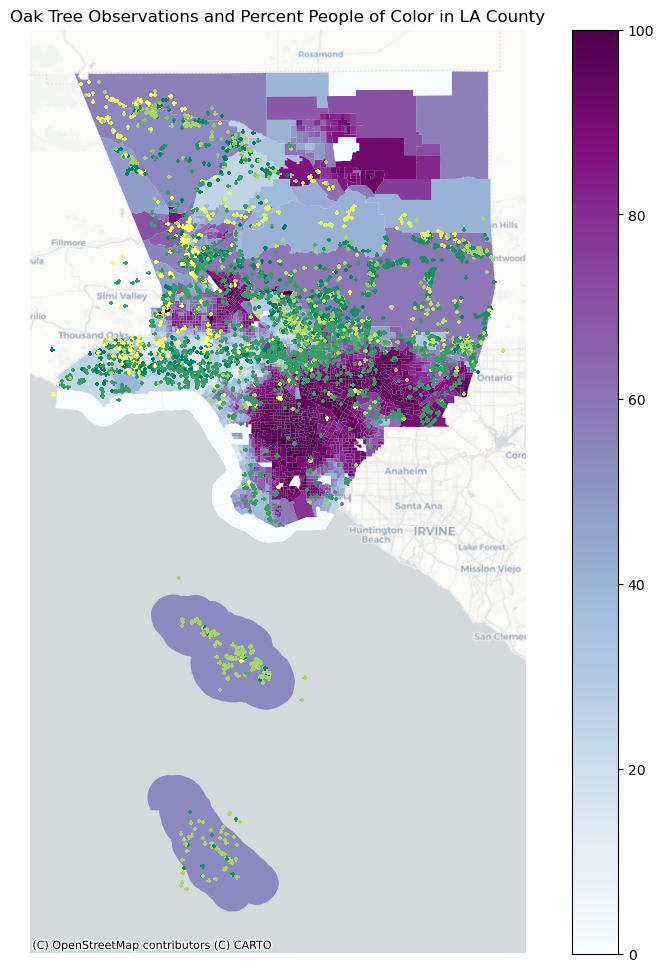

In [67]:
fig, ax = plt.subplots(figsize=(12,12))
tract_dem.plot(ax=ax,column='Percent Nonwhite',legend=True,cmap='BuPu')
geooak.plot(ax=ax, 
        marker='+',
        markersize=10,
        column='common_name',
        cmap='summer',
        legend = False,     
        legend_kwds={'loc':'upper left','bbox_to_anchor':(1,.9)})
ax.axis('off')
ax.set_title('Oak Tree Observations and Percent People of Color in LA County')
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=4326)
plt.savefig('Completed Maps/oakpocoverlay.jpg')

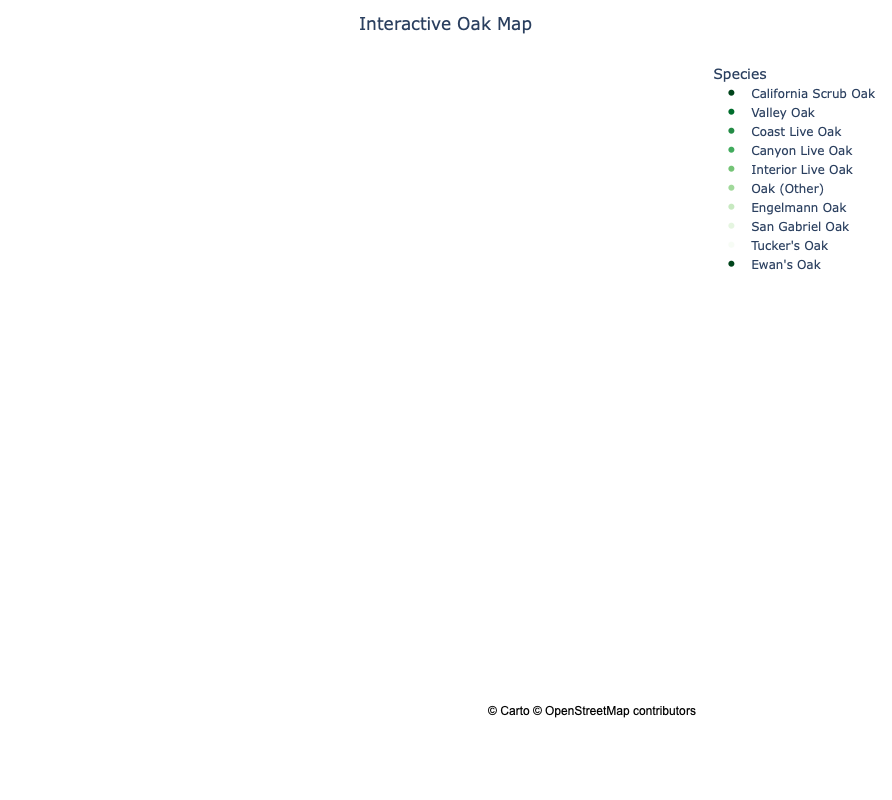

<Figure size 640x480 with 0 Axes>

In [71]:
# create an interactive plot of oak locations
oakpl = px.scatter_mapbox(geooak,
                        lat='latitude',
                        lon='longitude',
                        mapbox_style='carto-positron',
                        color='common_name',
                        color_discrete_sequence=px.colors.sequential.Greens_r,
                        labels={'common_name': 'Species'})
oakpl.update_layout(
    width = 800,
    height = 800,
    title = "Interactive Oak Map",
    title_x=0.5
)
# display the plot
oakpl.show()
plt.savefig('Completed Maps/interactiveoak.tif')

/tmp/ipykernel_165/668249211.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



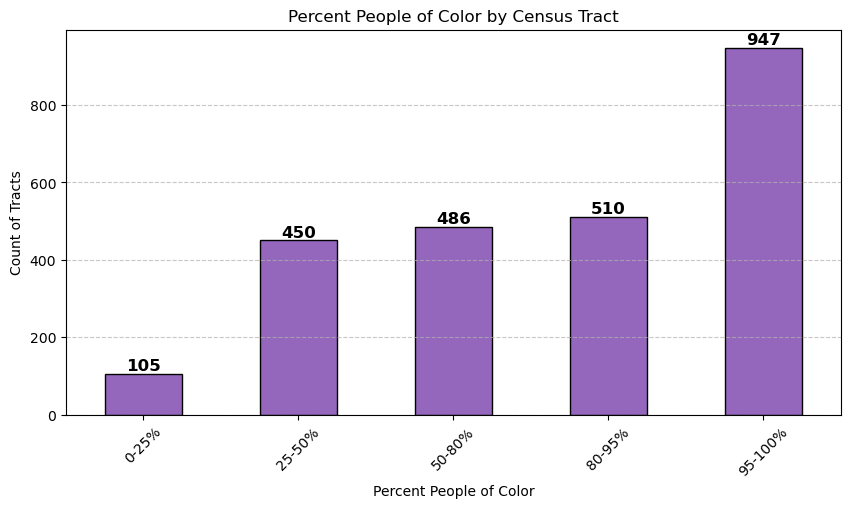

In [69]:
# Define custom bins (adjust as needed)
custom_bins = [0, 25, 50, 75, 90, 100]
bin_labels = ['0-25%', '25-50%', '50-80%', '80-95%', '95-100%']

# Assign data to bins
dem2['race_bins'] = pd.cut(dem2['Percent Nonwhite'], bins=custom_bins, labels=bin_labels, include_lowest=True)

# Count occurrences in each bin
bin_counts = dem2['race_bins'].value_counts().reindex(bin_labels)  # Ensure correct order

# Plot the data
plt.figure(figsize=(10, 5))
bin_counts.plot(kind='bar', color='#9467bd', edgecolor='black')

for i, count in enumerate(bin_counts):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')


# Formatting
plt.xlabel('Percent People of Color')
plt.ylabel('Count of Tracts')
plt.title('Percent People of Color by Census Tract')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()